In [ ]:
# ============================================================
# CELDA 1: Carga del Dataset de Imágenes Histopatológicas
# ============================================================
# Se descarga el dataset 'lung-cancer-histopathological-images' desde Kaggle
# usando kagglehub. Luego se recorren las clases (subcarpetas del dataset),
# se lee cada imagen, se redimensiona a 16x16 píxeles en RGB con OpenCV,
# y se almacena en las listas X (imágenes) e y (etiquetas numéricas).
# NOTA: El redimensionado a 16x16 es una simplificación para acelerar
# el procesamiento con modelos ML tradicionales.

import os
import kagglehub
import cv2
#cargar dataset
dataset_path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")
clases = sorted(os.listdir(dataset_path))
X = []
y = []
#convetir las images a 64*64 RGB
for label, clase in enumerate(clases):
    ruta = os.path.join(dataset_path, clase)
    for file in os.listdir(ruta):
            img_path = os.path.join(ruta, file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (16, 16))
            X.append(img)
            y.append(label)



100%|██████████| 1.55G/1.55G [01:30<00:00, 18.5MB/s]

Extracting files...


In [ ]:
# ============================================================
# CELDA 2: Aplanamiento (Flatten) y Verificación de Datos
# ============================================================
# Se convierte la lista de imágenes a un array NumPy y se aplana cada imagen
# de forma matricial (shape: [n_imagenes, 16*16*3] = [n, 768]) para que los
# modelos clásicos de sklearn puedan procesarlas como vectores de características.
# También se verifica que no haya valores nulos y se muestra la distribución de clases.

#haceer flatten
import numpy as np
X = np.array(X)

X_flat = X.reshape(len(X), -1)
Y = np.array(y)
print(f"Imágenes cargadas: {len(X)}")
print(f"Valores nulos en X_flat: {np.isnan(X_flat).sum()}")
print(f"Distribución de clases: {np.bincount(Y)}")

Imágenes cargadas: 15000
Valores nulos en X_flat: 0
Distribución de clases: [5000 5000 5000]


In [ ]:
# ============================================================
# CELDA 3: División Train/Test y Normalización de los Datos
# ============================================================
# Se divide el dataset en 80% entrenamiento y 20% prueba, manteniendo
# la proporción de clases (stratify=y) para evitar desbalances.
# Luego se normaliza con la media y desviación estándar del conjunto de
# entrenamiento (estandarización Z-score). Los píxeles con desviación cero
# se reemplazan por 1 para evitar divisiones por cero.
# IMPORTANTE: La normalización se calcula SOLO sobre train y se aplica a test,
# para no introducir data leakage.


from sklearn.model_selection import train_test_split
import numpy as np
#se crean los datos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

#normalizamos los datos
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1
X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std


Paso 1: Filtrando las 700 variables con un árbol rápido...
Reducción lista: Trabajando ahora con 45 variables.

Paso 2: Buscando la mejor configuración para el Decision Tree...


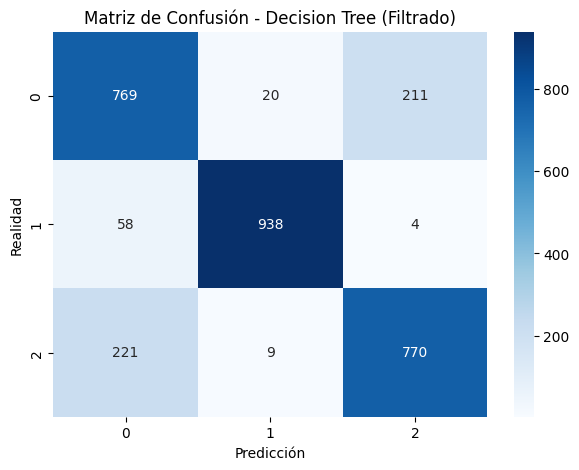

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      1000
           1       0.97      0.94      0.95      1000
           2       0.78      0.77      0.78      1000

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000

Accuracy Entrenamiento (Promedio): 0.8597
Accuracy Validación (Promedio):    0.8347
Diferencia (Brecha):               0.0250


In [ ]:
# ============================================================
# CELDA 4: Árbol de Decisión con RandomizedSearchCV
# ============================================================
# PASO 1 - Selección de variables: Se entrena un árbol de decisión 'sacrificable'
#   (max_depth=10) para obtener la importancia de cada feature y quedarse
#   con las 45 más relevantes, reduciendo dimensionalidad de ~768 a 45.
# PASO 2 - Búsqueda aleatoria: RandomizedSearchCV prueba 20 combinaciones
#   de hiperparámetros (criterio, profundidad, pesos de clase, etc.) con
#   validación cruzada de 3 folds para encontrar la mejor configuración.
# PASO 3 - Evaluación: Se genera la matriz de confusión, reporte de
#   clasificación y se mide la brecha entre accuracy de train y validación.

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# PASO 1: SELECCIÓN DE VARIABLES (EL DT SACRIFICABLE)
# ==========================================================
print("Paso 1: Filtrando las 700 variables con un árbol rápido...")
selector = DecisionTreeClassifier(max_depth=10, random_state=42)
selector.fit(X_train, y_train)

importancias = selector.feature_importances_
indices = np.argsort(importancias)[-45:]
X_train_red = X_train[:, indices]
X_test_red = X_test[:, indices]

print(f"Reducción lista: Trabajando ahora con {X_train_red.shape[1]} variables.\n")

# ==========================================================
# PASO 2: BÚSQUEDA ALEATORIA (DECISION TREE FINAL)
# ==========================================================
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, 25, 30],
    'min_samples_leaf': [10, 20, 30, 50],
    'min_samples_split': [20, 50, 100],
    'class_weight': ['balanced', None]
}

search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dt,
    n_iter=20,           # Suficientes intentos para 50 variables
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    random_state=42
)

print("Paso 2: Buscando la mejor configuración para el Decision Tree...")
search_dt.fit(X_train_red, y_train)

# ==========================================================
# PASO 3: EVALUACIÓN CON TU ESTRUCTURA
# ==========================================================
best_dt = search_dt.best_estimator_
y_pred = best_dt.predict(X_test_red)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Decision Tree (Filtrado)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# Reporte de Clasificación
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# Métricas y Brecha (Estructura idéntica a la anterior)
results = pd.DataFrame(search_dt.cv_results_)
best_row = results.loc[search_dt.best_index_]

train_acc = best_row['mean_train_score']
test_acc = best_row['mean_test_score']
gap = train_acc - test_acc

print(f"Accuracy Entrenamiento (Promedio): {train_acc:.4f}")
print(f"Accuracy Validación (Promedio):    {test_acc:.4f}")
print(f"Diferencia (Brecha):               {gap:.4f}")


In [ ]:
# ============================================================
# CELDA 5: Gráfica de Exploración - Decision Tree (RandomizedSearch)
# ============================================================
# Visualiza el accuracy de entrenamiento (puntos azules) y validación
# (puntos verdes) para cada una de las 20 combinaciones de hiperparámetros
# exploradas. La línea roja punteada señala la iteración con el mejor
# resultado en validación. Permite detectar visualmente overfitting
# (brecha grande entre train y test) o underfitting.



DecisionTreeClassifier(max_depth=20, min_samples_leaf=30, min_samples_split=100,
                       random_state=42)


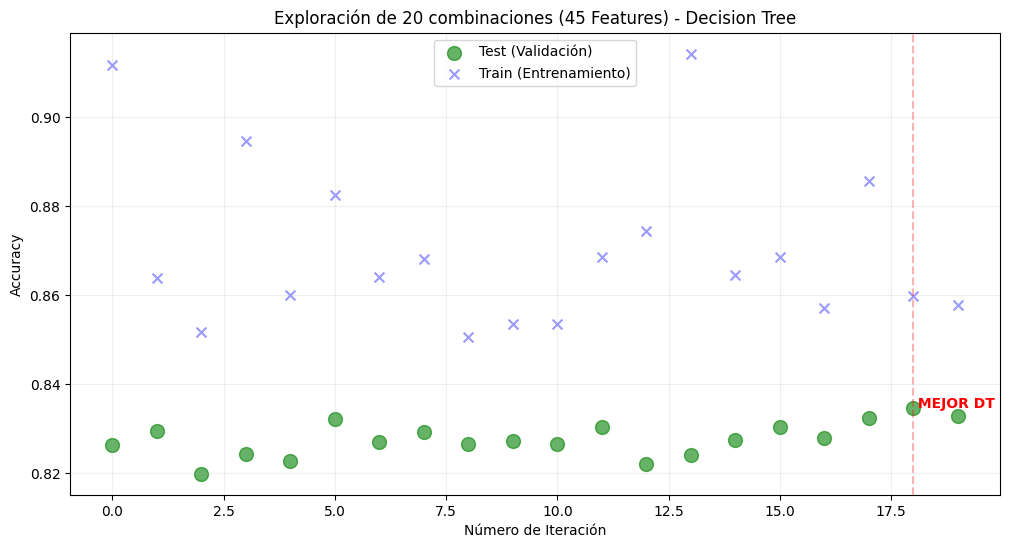

In [ ]:
# ============================================================
# CELDA 6: Random Forest con RandomizedSearchCV
# ============================================================
# PASO 1 - Selección de variables: Se reutiliza el árbol de decisión como
#   selector rápido de importancia, extrayendo las 45 features más relevantes.
# PASO 2 - Búsqueda aleatoria: Se prueban 10 combinaciones de hiperparámetros
#   del Random Forest (n_estimators, max_depth, min_samples_leaf, max_features,
#   class_weight) con CV de 3 folds.
# PASO 3 - Evaluación: Matriz de confusión (colormap verde), reporte de
#   clasificación y análisis de la brecha train/validación.

import pandas as pd
import matplotlib.pyplot as plt

# Extraemos los resultados directamente del search_dt que definiste
results_dt = pd.DataFrame(search_dt.cv_results_)

plt.figure(figsize=(12, 6))

# Graficamos todas las iteraciones (20 según tu n_iter)
# Círculos verdes para Test y equis azules para Train
plt.scatter(results_dt.index, results_dt['mean_test_score'], color='green', label='Test (Validación)', s=100, alpha=0.6)
plt.scatter(results_dt.index, results_dt['mean_train_score'], color='blue', label='Train (Entrenamiento)', marker='x', s=50, alpha=0.4)

# Resaltamos el mejor punto usando el índice del mejor resultado
best_idx_dt = search_dt.best_index_
plt.axvline(x=best_idx_dt, color='red', linestyle='--', alpha=0.3)
plt.text(best_idx_dt, results_dt['mean_test_score'][best_idx_dt], ' MEJOR DT', color='red', fontweight='bold')

# Título ajustado a tus 45 variables seleccionadas y 20 intentos
plt.title('Exploración de 20 combinaciones (45 Features) - Decision Tree')
plt.xlabel('Número de Iteración')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Paso 1: Filtrando 700 variables con un Random Forest rápido...
Reducción lista: Trabajando ahora con 45 variables clave.

Paso 2: Buscando la mejor configuración para el Random Forest...


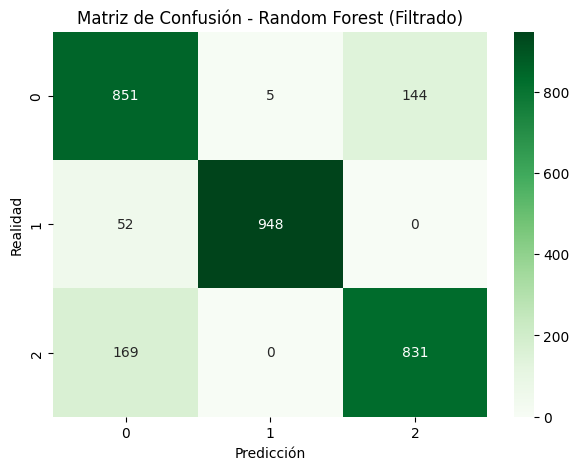

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.85      0.83      0.84      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000

Accuracy Entrenamiento (Promedio): 0.9012
Accuracy Validación (Promedio):    0.8795
Diferencia (Brecha):               0.0217


In [ ]:
# ============================================================
# CELDA 7: Gráfica de Exploración - Random Forest (RandomizedSearch)
# ============================================================
# Visualiza los scores de las 10 iteraciones del Random Forest:
# - Verde oscuro: accuracy en validación (test CV)
# - Azul: accuracy en entrenamiento
# La línea roja marca la mejor combinación encontrada. Se usa el índice
# del máximo de mean_test_score para identificar correctamente el mejor modelo.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# PASO 1: SELECCIÓN DE VARIABLES (RF SACRIFICABLE)
# ==========================================================
print("Paso 1: Filtrando 700 variables con un Random Forest rápido...")
# Entrenamos un bosque pequeño y veloz para detectar importancia
selector = DecisionTreeClassifier(max_depth=10, random_state=42)
selector.fit(X_train, y_train)

importancias = selector.feature_importances_
indices = np.argsort(importancias)[-45:]
X_train_red = X_train[:, indices]
X_test_red = X_test[:, indices]

print(f"Reducción lista: Trabajando ahora con {X_train_red.shape[1]} variables clave.\n")

# ==========================================================
# PASO 2: BÚSQUEDA ALEATORIA (RANDOM FOREST FINAL)
# ==========================================================
# Ajustamos los parámetros para que el bosque final sea eficiente
param_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, 25],
    'min_samples_leaf': [30, 40, 50],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=10,           # 10 intentos es suficiente al haber reducido variables
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    random_state=42
)

print("Paso 2: Buscando la mejor configuración para el Random Forest...")
search_rf.fit(X_train_red, y_train)

# ==========================================================
# PASO 3: EVALUACIÓN CON TU ESTRUCTURA
# ==========================================================
best_rf = search_rf.best_estimator_
y_pred = best_rf.predict(X_test_red)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') # Verde para el Bosque
plt.title('Matriz de Confusión - Random Forest (Filtrado)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# Reporte de Clasificación
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# Métricas y Brecha
results = pd.DataFrame(search_rf.cv_results_)
best_row = results.loc[search_rf.best_index_]

train_acc = best_row['mean_train_score']
test_acc = best_row['mean_test_score']
gap = train_acc - test_acc

print(f"Accuracy Entrenamiento (Promedio): {train_acc:.4f}")
print(f"Accuracy Validación (Promedio):    {test_acc:.4f}")
print(f"Diferencia (Brecha):               {gap:.4f}")

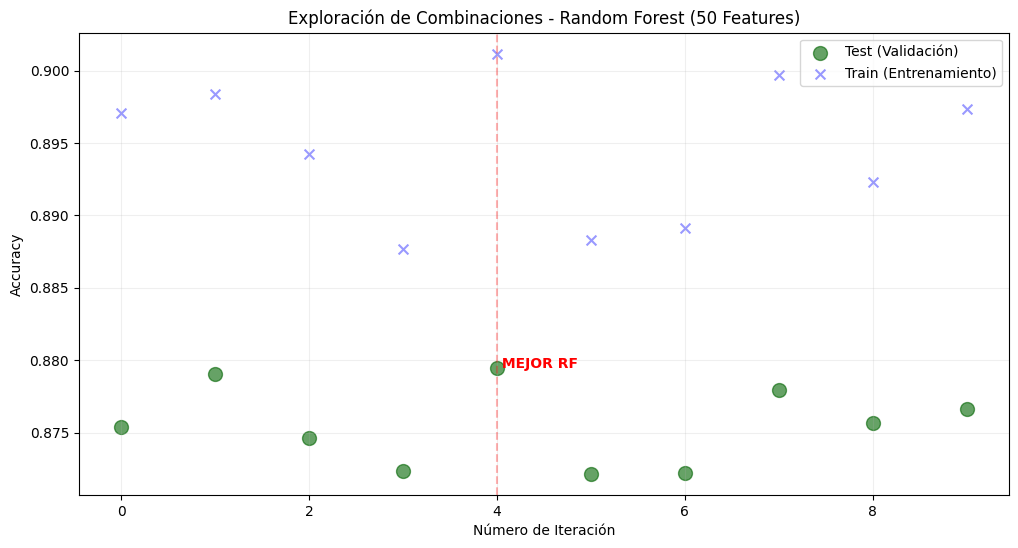

In [ ]:
# ============================================================
# CELDA 8: Support Vector Classifier (SVC) con RandomizedSearchCV
# ============================================================
# PASO 1 - Selección de variables: Igual que los modelos anteriores, se usan
#   las 45 features más importantes del árbol selector.
# PASO 2 - Búsqueda aleatoria: Se prueban 10 combinaciones de C (penalización),
#   gamma (influencia de muestras), kernel (rbf/poly/sigmoid) y class_weight.
#   Se limitan a 10 iteraciones porque el SVC es computacionalmente más costoso.
# PASO 3 - Evaluación: Matriz de confusión (colormap morado), reporte de
#   clasificación y análisis de brecha train/validación.

import pandas as pd
import matplotlib.pyplot as plt

# Cargamos los resultados de la búsqueda del Random Forest
results_rf = pd.DataFrame(search_rf.cv_results_)

plt.figure(figsize=(12, 6))

# Graficamos todas las iteraciones del Bosque
# Usamos un tono verde oscuro para el Test y azul para el Train
plt.scatter(results_rf.index, results_rf['mean_test_score'], color='darkgreen', label='Test (Validación)', s=100, alpha=0.6)
plt.scatter(results_rf.index, results_rf['mean_train_score'], color='blue', label='Train (Entrenamiento)', marker='x', s=50, alpha=0.4)

# Resaltamos el mejor punto encontrado por el Random Forest
best_idx_rf = results_rf['mean_test_score'].idxmax()
plt.axvline(x=best_idx_rf, color='red', linestyle='--', alpha=0.3)
plt.text(best_idx_rf, results_rf['mean_test_score'][best_idx_rf], ' MEJOR RF', color='red', fontweight='bold')

# Ajustamos el título con la cantidad de features que seleccionamos (50)
plt.title('Exploración de Combinaciones - Random Forest (50 Features)')
plt.xlabel('Número de Iteración')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Paso 1: Usando las variables más importantes para el SVC...
Reducción lista: SVC trabajando con 45 variables.

Paso 2: Buscando la mejor configuración para el SVC...
SVC(C=1, gamma=0.01, random_state=42)


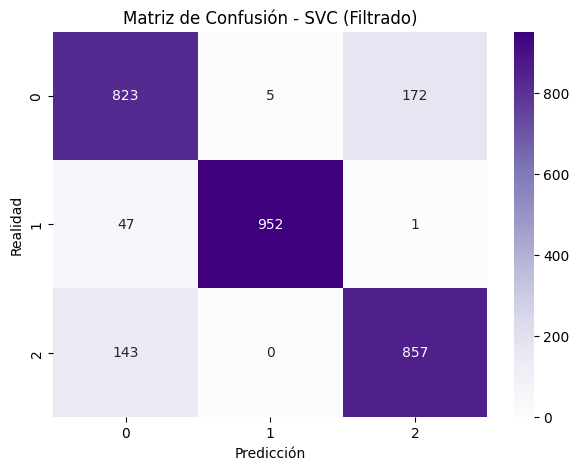

--- REPORTE DE CLASIFICACIÓN (SVC) ---
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.83      0.86      0.84      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000

Accuracy Entrenamiento (Promedio): 0.8900
Accuracy Validación (Promedio):    0.8745
Diferencia (Brecha):               0.0155


In [ ]:
# ============================================================
# CELDA 9: Gráfica de Exploración - SVC (RandomizedSearch)
# ============================================================
# Visualiza el accuracy de las 10 iteraciones del SVC:
# - Morado: accuracy en validación
# - Azul: accuracy en entrenamiento
# La marca 'MEJOR SVC' indica la iteración con mayor score de validación.

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# PASO 1: SELECCIÓN DE VARIABLES (REUTILIZAMOS EL FILTRO RF)
# ==========================================================
print("Paso 1: Usando las variables más importantes para el SVC...")
# (Asumimos que ya corriste el selector_rf anterior o lo definimos rápido aquí)
selector = DecisionTreeClassifier(max_depth=10, random_state=42)
selector.fit(X_train, y_train)

importancias = selector.feature_importances_
indices = np.argsort(importancias)[-45:]
X_train_red = X_train[:, indices]
X_test_red = X_test[:, indices]


print(f"Reducción lista: SVC trabajando con {X_train_red.shape[1]} variables.\n")

# ==========================================================
# PASO 2: BÚSQUEDA ALEATORIA (SVC)
# ==========================================================
# Nota: Para el SVC es vital usar valores en escala logarítmica para C y gamma
param_svc = {
    'C': [0.1, 1, 10, 100],             # Penalización por error
    'gamma': ['scale', 'auto', 0.01, 0.001], # Influencia de un solo ejemplo
    'kernel': ['rbf', 'poly', 'sigmoid'],    # Tipo de frontera
    'class_weight': ['balanced', None]

}
search_svc = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_svc,
    n_iter=10,           # El SVC es lento, 10 intentos es prudente
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    random_state=42
)

print("Paso 2: Buscando la mejor configuración para el SVC...")
search_svc.fit(X_train_red, y_train)

# ==========================================================
# PASO 3: EVALUACIÓN CON TU ESTRUCTURA
# ==========================================================
best_svc = search_svc.best_estimator_
print(best_svc)
y_pred = best_svc.predict(X_test_red)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples') # Púrpura para el SVC
plt.title('Matriz de Confusión - SVC (Filtrado)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# Reporte de Clasificación
print("--- REPORTE DE CLASIFICACIÓN (SVC) ---")
print(classification_report(y_test, y_pred))

# Métricas y Brecha
results_svc = pd.DataFrame(search_svc.cv_results_)
best_row = results_svc.loc[search_svc.best_index_]

train_acc = best_row['mean_train_score']
test_acc = best_row['mean_test_score']
gap = train_acc - test_acc

print(f"Accuracy Entrenamiento (Promedio): {train_acc:.4f}")
print(f"Accuracy Validación (Promedio):    {test_acc:.4f}")
print(f"Diferencia (Brecha):               {gap:.4f}")

# ==========================================================
# PASO 4: GRÁFICA DE EXPLORACIÓN
# ==========================================================


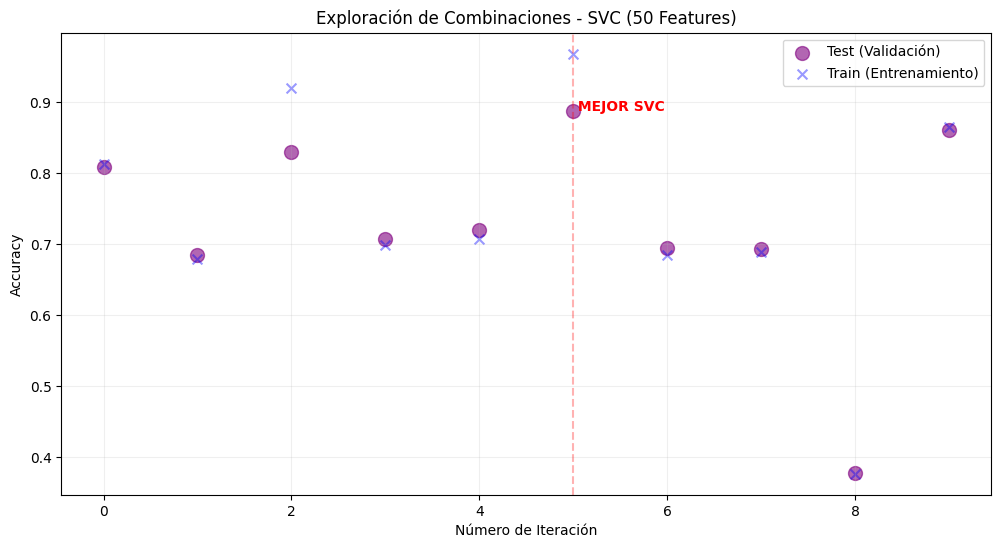

In [ ]:
# ============================================================
# CELDA 10: Selección de Variables con RFE y Optimización Bayesiana
# ============================================================
# PASO 1 - RFE (Recursive Feature Elimination): A diferencia de la selección
#   simple por importancia, RFE elimina features de forma iterativa
#   (step=0.20 = elimina 20% por ronda) hasta quedar con 50 variables.
#   Esto reduce la dimensionalidad de forma más rigurosa.
# PASO 2 - Optimización Bayesiana (BayesSearchCV): En lugar de búsqueda
#   aleatoria, usa un modelo probabilístico para explorar el espacio de
#   hiperparámetros de forma inteligente, priorizando regiones prometedoras.
#   Se definen espacios de búsqueda para DT, RF y SVC.
# ACELERADORES: Se usa float32 en lugar de float64 para reducir uso de
#   memoria, y el SVC tiene cache_size=1000 y max_iter=10000 para evitar
#   que se quede colgado en datos de alta dimensionalidad.

plt.figure(figsize=(12, 6))
plt.scatter(results_svc.index, results_svc['mean_test_score'], color='purple', label='Test (Validación)', s=100, alpha=0.6)
plt.scatter(results_svc.index, results_svc['mean_train_score'], color='blue', label='Train (Entrenamiento)', marker='x', s=50, alpha=0.4)

best_idx_svc = results_svc['mean_test_score'].idxmax()
plt.axvline(x=best_idx_svc, color='red', linestyle='--', alpha=0.3)
plt.text(best_idx_svc, results_svc['mean_test_score'][best_idx_svc], ' MEJOR SVC', color='red', fontweight='bold')

plt.title('Exploración de Combinaciones - SVC (50 Features)')
plt.xlabel('Número de Iteración')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# ============================================================
# CELDA 11: Tabla Comparativa - Optimización Bayesiana
# ============================================================
# Consolida los resultados de los tres modelos optimizados con Búsqueda
# Bayesiana en un DataFrame comparativo con columnas:
# - Train Acc: accuracy promedio en entrenamiento (indica capacidad de aprendizaje)
# - Test Acc: accuracy en validación cruzada (indica generalización)
# - Gap: diferencia entre ambos (indica nivel de overfitting)
# Se muestra ordenado de mayor a menor Test Acc para identificar el mejor modelo.

from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# ==========================================================
# PASO 1: SELECCIÓN DE VARIABLES (RFE VELOZ)
# ==========================================================
print(">>> Paso 1: Ejecutando RFE Light (Eliminación por bloques)...")

selector_motor = DecisionTreeClassifier(max_depth=10, random_state=42)

# Mantenemos tu lógica de step=0.20
rfe_veloz = RFE(estimator=selector_motor, n_features_to_select=50, step=0.20)
rfe_veloz.fit(X_train, y_train)

X_train_rfe = rfe_veloz.transform(X_train)
X_test_rfe = rfe_veloz.transform(X_test)

print(f"RFE terminado. De 700 a {X_train_rfe.shape[1]} variables.\n")

# ==========================================================
# PASO 2: FUNCIÓN DE OPTIMIZACIÓN BAYESIANA ENFOCADA
# ==========================================================
def ejecutar_bayes_enfocado(nombre, estimator, search_space, X_tr, y_tr):
    print(f"--- Optimizando {nombre} ---")
    opt = BayesSearchCV(
        estimator=estimator,
        search_spaces=search_space,
        n_iter=10,
        cv=2,
        n_jobs=-1,
        random_state=42,
        return_train_score=True
    )
    # ACELERADOR 1: Convertir a float32 reduce carga de CPU/RAM sin perder precisión
    opt.fit(X_tr.astype('float32'), y_tr)
    return opt

# --- Configuración de Espacios de Búsqueda ---
space_svc = {
    'C': Real(0.1, 10, prior='log-uniform'),
    'gamma': Categorical(['scale', 'auto', 0.01, 0.001]),
    'kernel': Categorical(['rbf', 'poly', 'sigmoid']),
    'class_weight': Categorical(['balanced', None])
}

space_rf = {
    'n_estimators': Integer(50, 150),
    'max_depth': Integer(10, 20),
    'min_samples_leaf': Integer(30, 50),
    'max_features': Categorical(['sqrt', 'log2']),
    'class_weight': Categorical(['balanced', None])
}

space_dt = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(10, 20),
    'min_samples_leaf': Integer(20, 50),
    'min_samples_split': Integer(50, 100),
    'class_weight': Categorical(['balanced', None])
}

# Ejecución de búsquedas
opt_dt = ejecutar_bayes_enfocado("Decision Tree", DecisionTreeClassifier(random_state=42), space_dt, X_train_rfe, y_train)
opt_rf = ejecutar_bayes_enfocado("Random Forest", RandomForestClassifier(random_state=42), space_rf, X_train_rfe, y_train)

# ACELERADOR 2: Inyectamos cache_size y max_iter directamente aquí para que el SVC no se trabe
opt_svc = ejecutar_bayes_enfocado(
    "SVC",
    SVC(random_state=42, cache_size=1000, max_iter=10000, tol=1e-3),
    space_svc,
    X_train_rfe,
    y_train
)



>>> Paso 1: Ejecutando RFE Light (Eliminación por bloques)...
RFE terminado. De 700 a 50 variables.

--- Optimizando Decision Tree ---
--- Optimizando Random Forest ---
--- Optimizando SVC ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
# ============================================================
# CELDA 12: Evaluación Final - Modelos con Optimización Bayesiana
# ============================================================
# Para cada modelo optimizado (DT, RF, SVC) se realiza la evaluación completa
# sobre el conjunto de TEST real (no validación cruzada):
# - classification_report: métricas por clase (precision, recall, F1, support)
# - confusion_matrix: visualización de aciertos y errores por clase
# Los colormaps diferenciados (Greens/Blues/Oranges) facilitan la comparación
# visual rápida entre modelos.

# Unimos los resultados en una sola tabla comparativa
resumen = pd.DataFrame([{
    'Modelo': nom,
    'Train Acc': round(opt.cv_results_['mean_train_score'][opt.best_index_], 4),
    'Test Acc': round(opt.best_score_, 4),
    'Gap': round(opt.cv_results_['mean_train_score'][opt.best_index_] - opt.best_score_, 4)
} for nom, opt in [('DT', opt_dt), ('RF', opt_rf), ('SVC', opt_svc)]])

# Mostramos la tabla ordenada por el mejor desempeño en Test
print(resumen.sort_values('Test Acc', ascending=False).to_string(index=False))

Modelo  Train Acc  Test Acc    Gap
   SVC     0.9688    0.8884 0.0803
    RF     0.8952    0.8742 0.0210
    DT     0.8657    0.8181 0.0476



EVALUACIÓN: DECISION TREE
              precision    recall  f1-score   support

           0       0.75      0.76      0.75      1000
           1       0.98      0.93      0.95      1000
           2       0.77      0.81      0.79      1000

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



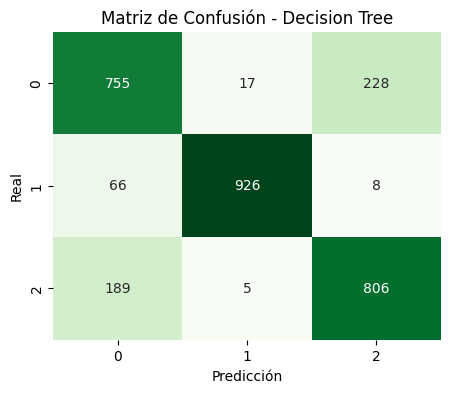


EVALUACIÓN: RANDOM FOREST
              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.85      0.84      0.84      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



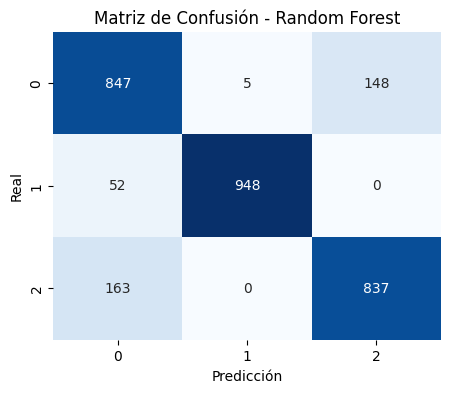


EVALUACIÓN: SVC
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1000
           1       0.99      0.98      0.98      1000
           2       0.86      0.87      0.86      1000

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



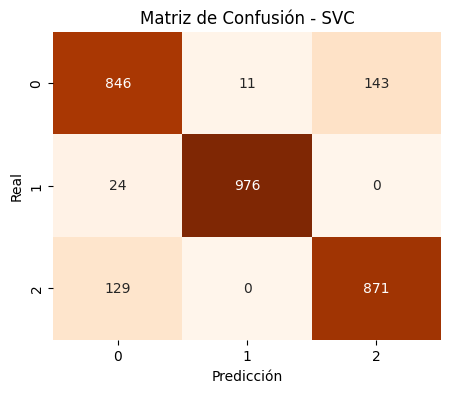

In [ ]:
# ============================================================
# CELDA 13: Curvas ROC por Modelo (Clasificación Multiclase)
# ============================================================
# Para clasificación multiclase se usa la estrategia One-vs-Rest:
# se binariza y_test (una columna por clase) y se traza una curva ROC
# por cada clase. Si el modelo tiene predict_proba se usa esa función;
# si no (caso del SVC lineal), se usa decision_function como score.
# Un AUC cercano a 1.0 indica excelente discriminación de la clase.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Asegúrate de usar X_test_rfe para que coincida con las 50 variables del RFE
X_test_eval = X_test_rfe.astype('float32')

# --- PLOTS Y CLASIFICACIÓN: DECISION TREE ---
print("\n" + "="*30)
print("EVALUACIÓN: DECISION TREE")
print("="*30)
y_pred_dt = opt_dt.predict(X_test_eval)
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Decision Tree')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# --- PLOTS Y CLASIFICACIÓN: RANDOM FOREST ---
print("\n" + "="*30)
print("EVALUACIÓN: RANDOM FOREST")
print("="*30)
y_pred_rf = opt_rf.predict(X_test_eval)
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# --- PLOTS Y CLASIFICACIÓN: SVC ---
print("\n" + "="*30)
print("EVALUACIÓN: SVC")
print("="*30)
y_pred_svc = opt_svc.predict(X_test_eval)
print(classification_report(y_test, y_pred_svc))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matriz de Confusión - SVC')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

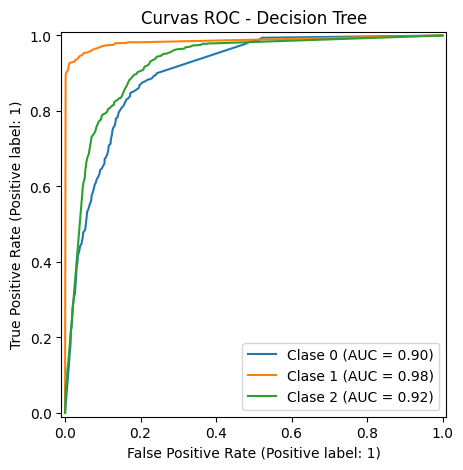

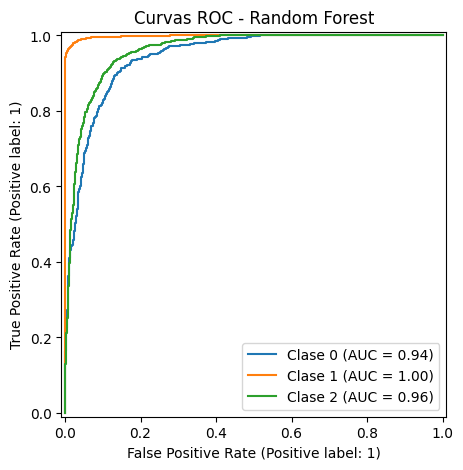

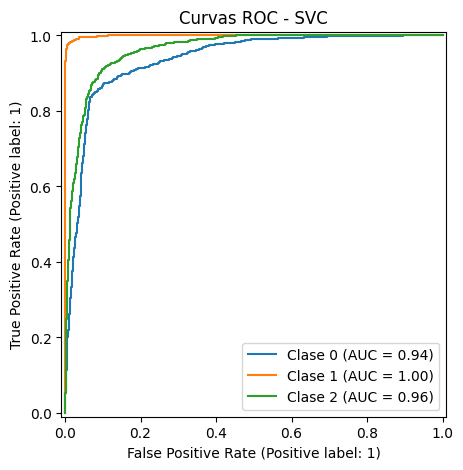

In [ ]:
# ============================================================
# CELDA 14: Gráficas Train vs Test - Convergencia por Modelo (Bayesian)
# ============================================================
# Para DT, RF y SVC (optimización bayesiana) se visualiza la evolución
# del accuracy de entrenamiento y validación a lo largo de las iteraciones.
# El área sombreada entre ambas curvas representa el 'gap' (overfitting):
# - Gap pequeño y constante: modelo bien regularizado
# - Gap creciente: señal de sobreajuste
# Permite comparar la estabilidad de cada modelo durante la optimización.

from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for nombre, modelo in [('Decision Tree', opt_dt),
                        ('Random Forest', opt_rf),
                        ('SVC', opt_svc)]:
    y_score = modelo.predict_proba(X_test_rfe.astype('float32')) \
              if hasattr(modelo.best_estimator_, 'predict_proba') \
              else modelo.decision_function(X_test_rfe.astype('float32'))

    fig, ax = plt.subplots(figsize=(7, 5))
    for i in range(3):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_score[:, i] if y_score.ndim > 1 else y_score,
            name=f"Clase {i}",
            ax=ax
        )
    ax.set_title(f'Curvas ROC - {nombre}')
    plt.show()

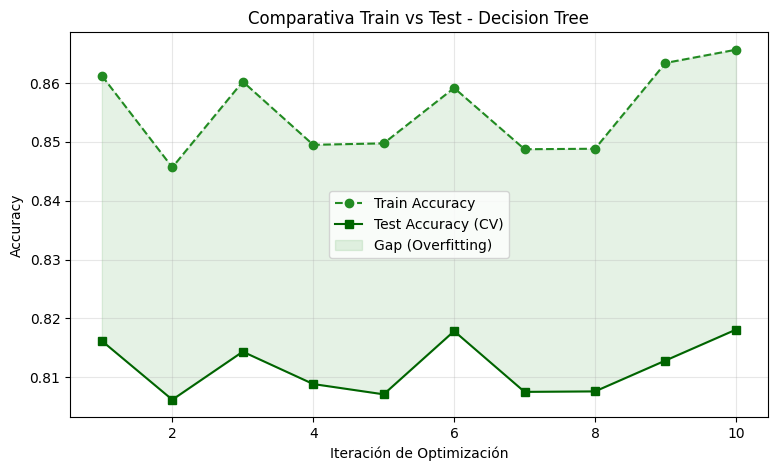

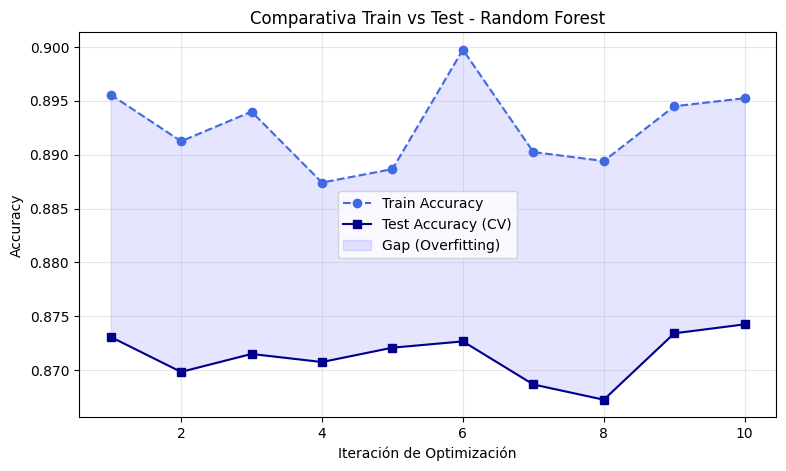

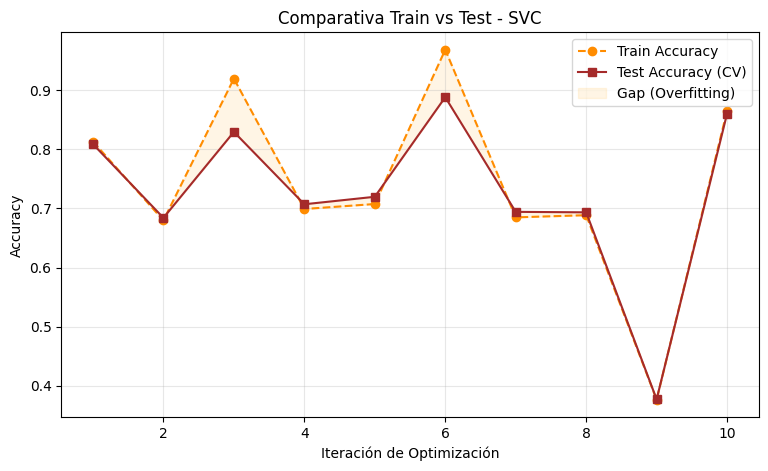

In [ ]:
# ============================================================
# CELDA 15: Validación Cruzada K-Fold (3 folds) - Comparativa
# ============================================================
# Se aplica StratifiedKFold (mantiene proporción de clases en cada fold)
# con 3 particiones para comparar de forma justa todos los modelos:
# - RandomizedSearch: DT, RF y SVC con las 45 features del selector simple
# - Optimización Bayesiana: DT, RF y SVC con las 50 features del RFE
# Se reporta el accuracy promedio ± desviación estándar para medir
# tanto el rendimiento como la estabilidad entre folds.

import matplotlib.pyplot as plt

# ==========================================================
# COMPARATIVA TRAIN VS TEST: DECISION TREE
# ==========================================================
train_scores_dt = opt_dt.cv_results_['mean_train_score']
test_scores_dt = opt_dt.cv_results_['mean_test_score']

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_scores_dt) + 1), train_scores_dt, label='Train Accuracy', marker='o', color='forestgreen', linestyle='--')
plt.plot(range(1, len(test_scores_dt) + 1), test_scores_dt, label='Test Accuracy (CV)', marker='s', color='darkgreen')
plt.fill_between(range(1, len(train_scores_dt) + 1), train_scores_dt, test_scores_dt, color='green', alpha=0.1, label='Gap (Overfitting)')

plt.title('Comparativa Train vs Test - Decision Tree')
plt.xlabel('Iteración de Optimización')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# COMPARATIVA TRAIN VS TEST: RANDOM FOREST
# ==========================================================
train_scores_rf = opt_rf.cv_results_['mean_train_score']
test_scores_rf = opt_rf.cv_results_['mean_test_score']

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_scores_rf) + 1), train_scores_rf, label='Train Accuracy', marker='o', color='royalblue', linestyle='--')
plt.plot(range(1, len(test_scores_rf) + 1), test_scores_rf, label='Test Accuracy (CV)', marker='s', color='darkblue')
plt.fill_between(range(1, len(train_scores_rf) + 1), train_scores_rf, test_scores_rf, color='blue', alpha=0.1, label='Gap (Overfitting)')

plt.title('Comparativa Train vs Test - Random Forest')
plt.xlabel('Iteración de Optimización')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# COMPARATIVA TRAIN VS TEST: SVC
# ==========================================================
train_scores_svc = opt_svc.cv_results_['mean_train_score']
test_scores_svc = opt_svc.cv_results_['mean_test_score']

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(train_scores_svc) + 1), train_scores_svc, label='Train Accuracy', marker='o', color='darkorange', linestyle='--')
plt.plot(range(1, len(test_scores_svc) + 1), test_scores_svc, label='Test Accuracy (CV)', marker='s', color='brown')
plt.fill_between(range(1, len(train_scores_svc) + 1), train_scores_svc, test_scores_svc, color='orange', alpha=0.1, label='Gap (Overfitting)')

plt.title('Comparativa Train vs Test - SVC')
plt.xlabel('Iteración de Optimización')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# CELDA 16: Red Neuronal Profunda (DNN) con Keras/TensorFlow
# ============================================================
# Se construye una DNN secuencial con 3 capas ocultas (128 → 64 → 32 neuronas,
# activación ReLU) y una capa de salida de 3 neuronas con softmax para
# clasificación multiclase.
# - Compilación: optimizador Adam + pérdida categorical_crossentropy
# - EarlyStopping: detiene el entrenamiento si val_loss no mejora en 5 épocas
#   y restaura los mejores pesos, evitando sobreajuste
# - Entrenamiento: máx 50 épocas con batch_size=32 y 20% de validación interna
# Al final se genera la matriz de confusión, reporte de clasificación
# y curvas ROC para comparar con los modelos ML clásicos.

from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=== K-Fold - RandomizedSearch ===")
for nombre, modelo in [('Decision Tree', search_dt.best_estimator_),
                        ('Random Forest', search_rf.best_estimator_),
                        ('SVC', search_svc.best_estimator_)]:
    scores = cross_val_score(modelo, X_train_red.astype('float32'), y_train, cv=kf, scoring='accuracy')
    print(f"{nombre} → K-Fold Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n=== K-Fold - Bayesian Optimization ===")
for nombre, modelo in [('Decision Tree', opt_dt.best_estimator_),
                        ('Random Forest', opt_rf.best_estimator_),
                        ('SVC', opt_svc.best_estimator_)]:
    scores = cross_val_score(modelo, X_train_rfe.astype('float32'), y_train, cv=kf, scoring='accuracy')
    print(f"{nombre} → K-Fold Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

=== K-Fold - RandomizedSearch ===
Decision Tree → K-Fold Accuracy: 0.8312 ± 0.0039
Random Forest → K-Fold Accuracy: 0.8780 ± 0.0013
SVC → K-Fold Accuracy: 0.8799 ± 0.0031

=== K-Fold - Bayesian Optimization ===
Decision Tree → K-Fold Accuracy: 0.8284 ± 0.0026
Random Forest → K-Fold Accuracy: 0.8752 ± 0.0027
SVC → K-Fold Accuracy: 0.8962 ± 0.0021


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,963 (66.26 KB)

 Trainable params: 16,963 (66.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7847 - loss: 0.4660 - val_accuracy: 0.8363 - val_loss: 0.3810
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8485 - loss: 0.3484 - val_accuracy: 0.8562 - val_loss: 0.3314
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8764 - loss: 0.2907 - val_accuracy: 0.8567 - val_loss: 0.3448
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8998 - loss: 0.2454 - val_accuracy: 0.8729 - val_loss: 0.3026
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9140 - loss: 0.2147 - val_accuracy: 0.8712 - val_loss: 0.3071
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9242 - loss: 0.1932 - val_accuracy: 0.8779 - val_loss: 0.3065
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9331 - loss: 0.1688 - val_accuracy: 0.8779 - val_loss: 0.3119
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9401 - loss: 0.1515 - val_accuracy: 0.

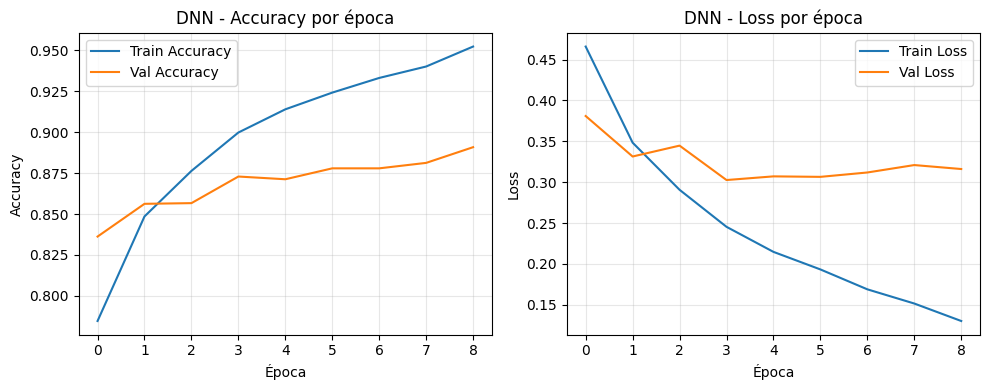

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== REPORTE DE CLASIFICACIÓN - DNN ===
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.83      0.86      0.84      1000

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



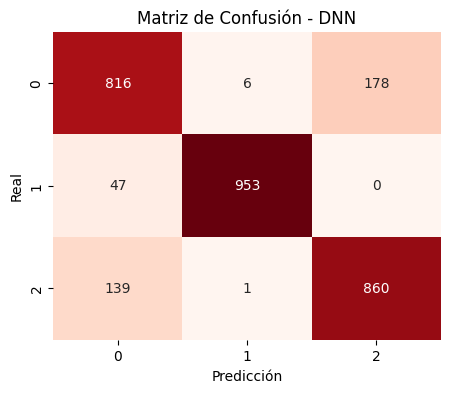

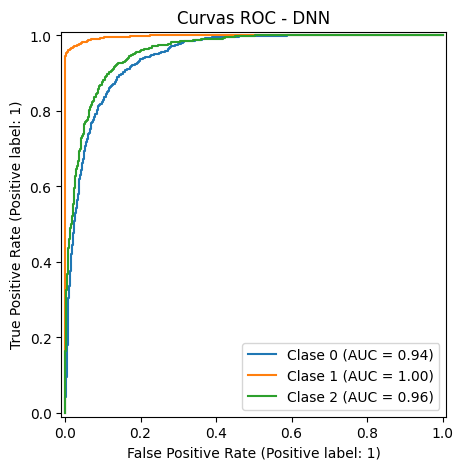

=== COMPARATIVA FINAL - Test Accuracy ===
SVC - Bayesian                 → 0.8977
SVC - RandomizedSearch         → 0.8817
RF  - Bayesian                 → 0.8773
RF  - RandomizedSearch         → 0.8767
DNN                            → 0.8763
DT  - Bayesian                 → 0.8290
DT  - RandomizedSearch         → 0.8257


In [ ]:
# ============================================================
# CELDA 17: Comparativa Final - K-Fold y Accuracy en Test
# ============================================================
# SECCIÓN K-FOLD: Evalúa todos los modelos ML (RandomizedSearch y Bayesiano)
#   con StratifiedKFold(3) sobre el conjunto de entrenamiento, más la DNN
#   evaluada fold a fold con model.evaluate().
#   Resultado: accuracy promedio ± std ordenado de mayor a menor.
# SECCIÓN TEST FINAL: Evalúa cada modelo directamente sobre el conjunto
#   de test real (X_test), mostrando el accuracy final de despliegue.
# Esta doble comparativa permite identificar el modelo con mejor
# generalización y menor varianza entre folds.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# ==========================================================
# DATOS
# ==========================================================
X_tr = X_train_rfe.astype('float32')
X_te = X_test_rfe.astype('float32')

y_tr = keras.utils.to_categorical(y_train, num_classes=3)
y_te = keras.utils.to_categorical(y_test,  num_classes=3)

# ==========================================================
# ARQUITECTURA
# ==========================================================
model_dnn = keras.Sequential([
    layers.Flatten(input_shape=(X_tr.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(3,   activation='softmax')
])

model_dnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_dnn.summary()

# ==========================================================
# ENTRENAMIENTO
# ==========================================================
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model_dnn.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# GRÁFICA TRAIN VS VAL
# ==========================================================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN - Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN - Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# MATRIZ DE CONFUSIÓN Y REPORTE
# ==========================================================
y_pred_prob = model_dnn.predict(X_te)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_te, axis=1)

print("\n=== REPORTE DE CLASIFICACIÓN - DNN ===")
print(classification_report(y_true, y_pred))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Matriz de Confusión - DNN')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# ==========================================================
# CURVAS ROC
# ==========================================================
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(3):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_pred_prob[:, i],
        name=f"Clase {i}",
        ax=ax
    )
ax.set_title('Curvas ROC - DNN')
plt.show()

# ==========================================================
# PASO 8: COMPARATIVA FINAL RNN vs ML TRADICIONAL
# ==========================================================


In [ ]:
# ============================================================
# CELDA 18: (Celda de cierre / espacio de trabajo adicional)
# ============================================================
# Espacio reservado para análisis adicionales, conclusiones finales
# o experimentos complementarios del proyecto.

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=== COMPARATIVA FINAL - kfold ===")

comparativa_ml = [
    ('DT  - RandomizedSearch', search_dt.best_estimator_,  X_test_red, X_train_red),
    ('RF  - RandomizedSearch', search_rf.best_estimator_,  X_test_red, X_train_red),
    ('SVC - RandomizedSearch', search_svc.best_estimator_, X_test_red, X_train_red),
    ('DT  - Bayesian',         opt_dt.best_estimator_,     X_test_rfe, X_train_rfe),
    ('RF  - Bayesian',         opt_rf.best_estimator_,     X_test_rfe, X_train_rfe),
    ('SVC - Bayesian',         opt_svc.best_estimator_,    X_test_rfe, X_train_rfe),
]

resultados = []

for nombre, modelo, X_te_mod, X_tr_mod in comparativa_ml:
    scores = cross_val_score(modelo, X_tr_mod.astype('float32'), y_train, cv=kf, scoring='accuracy')
    resultados.append((nombre, scores.mean(), scores.std()))

# DNN aparte porque es Keras
dnn_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_tr, y_train)):
    _, acc = model_dnn.evaluate(X_tr[val_idx], y_tr[val_idx], verbose=0)
    dnn_scores.append(acc)
dnn_scores = np.array(dnn_scores)
dnn_scores = np.array(dnn_scores)
resultados.append(('DNN', dnn_scores.mean(), dnn_scores.std()))

# Imprimir ordenado
for nombre, mean, std in sorted(resultados, key=lambda x: x[1], reverse=True):
    print(f"{nombre:30s} → {mean:.4f} ± {std:.4f}")
print("----TESTEO----")
comparativa = [
    ('DT  - RandomizedSearch', search_dt.best_estimator_.score(X_test_red, y_test)),
    ('RF  - RandomizedSearch', search_rf.best_estimator_.score(X_test_red, y_test)),
    ('SVC - RandomizedSearch', search_svc.best_estimator_.score(X_test_red, y_test)),
    ('DT  - Bayesian',         opt_dt.best_estimator_.score(X_test_rfe, y_test)),
    ('RF  - Bayesian',         opt_rf.best_estimator_.score(X_test_rfe, y_test)),
    ('SVC - Bayesian',         opt_svc.best_estimator_.score(X_test_rfe, y_test)),
    ('DNN',                    model_dnn.evaluate(X_te, y_te, verbose=0)[1]),
]

for nombre, acc in sorted(comparativa, key=lambda x: x[1], reverse=True):
    print(f"{nombre:30s} → {acc:.4f}")

=== COMPARATIVA FINAL - kfold ===
DNN                            → 0.9117 ± 0.0012
SVC - Bayesian                 → 0.8962 ± 0.0021
SVC - RandomizedSearch         → 0.8799 ± 0.0031
RF  - RandomizedSearch         → 0.8780 ± 0.0013
RF  - Bayesian                 → 0.8752 ± 0.0027
DT  - RandomizedSearch         → 0.8312 ± 0.0039
DT  - Bayesian                 → 0.8284 ± 0.0026
----TESTEO----
SVC - Bayesian                 → 0.8977
SVC - RandomizedSearch         → 0.8817
RF  - Bayesian                 → 0.8773
RF  - RandomizedSearch         → 0.8767
DNN                            → 0.8763
DT  - Bayesian                 → 0.8290
DT  - RandomizedSearch         → 0.8257
